In [1]:
import pandas as pd
import numpy as np

import torch

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_recall_fscore_support
)

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/kaggle/input/datasets/shuvammaity40/roberta/train.csv")

print(df.shape)

(159571, 8)


In [3]:
label_cols = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

df["labels"] = (
    df[label_cols]
    .sum(axis=1)
    .gt(0)
    .astype(int)
)

df = df[
    ["comment_text", "labels"]
]

df.head()

,comment_text,labels
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0


In [4]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["labels"],
    random_state=42
)

print(train_df.shape)
print(val_df.shape)

(127656, 2)
(31915, 2)


In [5]:
train_ds = Dataset.from_pandas(train_df)

val_ds = Dataset.from_pandas(val_df)

In [6]:
model_name = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [7]:
def tokenize(batch):

    return tokenizer(
        batch["comment_text"],
        truncation=True,
        max_length=256
    )

In [8]:
train_ds = train_ds.map(
    tokenize,
    batched=True
)

val_ds = val_ds.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/127656 [00:00<?, ? examples/s]

Map:   0%|          | 0/31915 [00:00<?, ? examples/s]

In [9]:
train_ds.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels"
    ]
)

val_ds.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels"
    ]
)

In [10]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [12]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(
        logits,
        axis=1
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            preds,
            average="binary"
        )
    )

    accuracy = accuracy_score(
        labels,
        preds
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [13]:
training_args = TrainingArguments(

    output_dir="./roberta-toxic",

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    save_total_limit=1,

    num_train_epochs=5,

    learning_rate=2e-5,

    weight_decay=0.01,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    fp16=True,

    logging_steps=100,

    report_to="none"
)

In [14]:
callbacks = [
    EarlyStoppingCallback(
        early_stopping_patience=2
    )
]

In [15]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    #tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=callbacks
)

In [16]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.189732,0.247150,0.965377,0.939245,0.705085,0.805492
2,0.182064,0.221078,0.968917,0.885920,0.796918,0.839066
3,0.111705,0.312724,0.964687,0.797305,0.875193,0.834435
4,0.077727,0.347114,0.967351,0.837366,0.842527,0.839939
5,0.045335,0.410055,0.966129,0.819929,0.854545,0.836879


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=19950, training_loss=0.12613021268581687, metrics={'train_runtime': 16524.9634, 'train_samples_per_second': 38.625, 'train_steps_per_second': 1.207, 'total_flos': 8.259623772074544e+16, 'train_loss': 0.12613021268581687, 'epoch': 5.0})

In [17]:
load_best_model_at_end=True

In [18]:
results = trainer.evaluate()

results

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.34759801626205444,
 'eval_accuracy': 0.9673194422685257,
 'eval_precision': 0.837109614206981,
 'eval_recall': 0.8425269645608628,
 'eval_f1': 0.8398095530640455,
 'eval_runtime': 248.1648,
 'eval_samples_per_second': 128.604,
 'eval_steps_per_second': 4.022,
 'epoch': 5.0}

In [19]:
predictions = trainer.predict(
    val_ds
)

preds = np.argmax(
    predictions.predictions,
    axis=1
)

print(
    classification_report(
        predictions.label_ids,
        preds
    )
)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


              precision    recall  f1-score   support

           0       0.98      0.98      0.98     28670
           1       0.84      0.84      0.84      3245

    accuracy                           0.97     31915
   macro avg       0.91      0.91      0.91     31915
weighted avg       0.97      0.97      0.97     31915



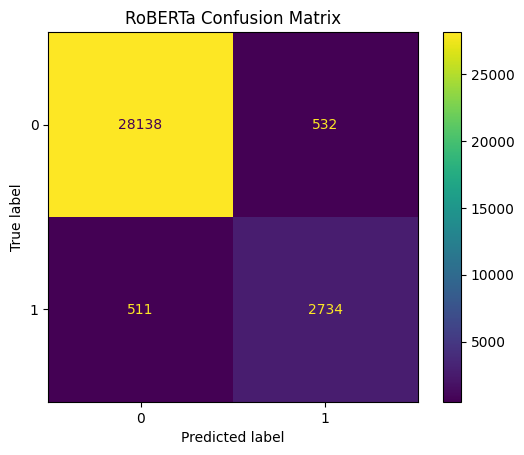

In [20]:
cm = confusion_matrix(
    predictions.label_ids,
    preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("RoBERTa Confusion Matrix")

plt.show()

In [21]:
trainer.save_model(
    "/kaggle/working/best_roberta_model"
)

tokenizer.save_pretrained(
    "/kaggle/working/best_roberta_model"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/kaggle/working/best_roberta_model/tokenizer_config.json',
 '/kaggle/working/best_roberta_model/tokenizer.json')

In [22]:
!zip -r roberta_model.zip /kaggle/working/best_roberta_model

  adding: kaggle/working/best_roberta_model/ (stored 0%)
  adding: kaggle/working/best_roberta_model/tokenizer_config.json (deflated 50%)
  adding: kaggle/working/best_roberta_model/model.safetensors (deflated 7%)
  adding: kaggle/working/best_roberta_model/tokenizer.json (deflated 82%)
  adding: kaggle/working/best_roberta_model/training_args.bin (deflated 53%)
  adding: kaggle/working/best_roberta_model/config.json (deflated 51%)
